# Predictive Maintenance for Marine Engines
## Analysis and Machine Learning Classification

## Project Overview

This project develops a predictive maintenance system for marine engines using machine learning classification. The system categorizes engine conditions into three maintenance statuses:
- **Critical**: Immediate maintenance required  
- **Requires Maintenance**: Scheduled maintenance recommended  
- **Normal**: No maintenance required  

The analysis utilizes a simulated dataset representing two years of operational data (2023-2024) from 50 marine engines with 5,000+ records.

## Dataset Details

The dataset comprises numerical, categorical, and target variables:

### Numerical Features (10)
- `engine_temp` (°C)
- `oil_pressure` (bar)
- `fuel_consumption` (L/hr)
- `vibration_level` (mm/s)
- `rpm` (rev/min)
- `engine_load` (%)
- `coolant_temp` (°C)
- `exhaust_temp` (°C)
- `running_period` (hours per week, 0 - 168)

### Categorical Features (5)
- `failure_mode` (`Mechanical Wear`, `No Failure`, `Overheating`, `Oil Leakage`)
- `engine_type` (`2-stroke Medium-Speed`, `2-stroke Low-Speed`, `4-stroke Medium-Speed`, `4-stroke High-Speed`)
- `fuel_type` (`Diesel`, `HFO`)
- `manufacturer` (Realistic marine engine brands)
- `engine_id` (Unique identifier)

### Target Variable
- `maintenance_status` (`Critical`, `Requires Maintenance`, `Normal`) - Balanced distribution

## Data Preprocessing

The pipeline includes:
1. Feature Scaling: Standardizing numerical features  
2. Categorical Encoding: One-Hot Encoding for categorical features  
3. Dimensionality Reduction: PCA (n_components=0.95)  
4. Model Training: Decision Tree, Random Forest, and XGBoost

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from joblib import Parallel, delayed
from sklearn.preprocessing import LabelEncoder
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Loading dataset
df = pd.read_csv('input/marine_engine_data.csv')
df.tail()

,timestamp,engine_id,engine_temp,oil_pressure,fuel_consumption,vibration_level,rpm,engine_load,coolant_temp,exhaust_temp,running_period,fuel_consumption_per_hour,maintenance_status,failure_mode,engine_type,fuel_type,manufacturer
5195,2024-11-24,ENG_050,92.745290,7.956103,7680.773408,3.961213,1357.996911,67.879882,93.227957,450.0,109.063800,100.0,Critical,Overheating,2-stroke Medium-Speed,HFO,Caterpillar
5196,2024-12-01,ENG_050,89.462079,8.000000,1265.703232,3.895100,1525.999645,64.312763,85.860150,450.0,41.032231,100.0,Normal,Oil Leakage,4-stroke High-Speed,Diesel,MAN B&W
5197,2024-12-08,ENG_050,79.057910,6.413932,4052.497442,3.272452,1287.392745,23.827673,82.431163,450.0,151.801942,100.0,Normal,Oil Leakage,4-stroke Medium-Speed,HFO,MAN B&W
5198,2024-12-15,ENG_050,79.379851,7.437593,1000.000000,3.450956,1584.249476,43.233388,75.937160,450.0,16.715902,100.0,Critical,Mechanical Wear,2-stroke Medium-Speed,HFO,Rolls-Royce
5199,2024-12-22,ENG_050,78.091169,7.137819,3589.190365,3.824081,1669.367989,36.965927,72.909996,450.0,110.235183,100.0,Requires Maintenance,Mechanical Wear,2-stroke Medium-Speed,Diesel,Rolls-Royce


## Dataset Profiling and Initial Insights

In [2]:
# Function to check the dataset
def explore_engine_data(df):
    print('Dataset Overview:')
    print(f"Number of Rows: {df.shape[0]}")
    print(f"Number of Columns: {df.shape[1]}")

    print('\n Column Names')
    print(df.columns.tolist())

    print('\n Datatypes & Non-Null Values:')
    print(df.info())

    print('Descriptive Statistics for Numerical Columns:')
    print(df.describe(exclude='O').T)
    
    print('Descriptive Statistics for Categorical Columns:')
    print(df.describe(include='O').T)

    print('Missing Values:')
    print(df.isnull().sum())

    return

In [3]:
explore_engine_data(df)

Dataset Overview:
Number of Rows: 5200
Number of Columns: 17

 Column Names
['timestamp', 'engine_id', 'engine_temp', 'oil_pressure', 'fuel_consumption', 'vibration_level', 'rpm', 'engine_load', 'coolant_temp', 'exhaust_temp', 'running_period', 'fuel_consumption_per_hour', 'maintenance_status', 'failure_mode', 'engine_type', 'fuel_type', 'manufacturer']

 Datatypes & Non-Null Values:
<class 'pandas.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   timestamp                  5200 non-null   str    
 1   engine_id                  5200 non-null   str    
 2   engine_temp                5200 non-null   float64
 3   oil_pressure               5200 non-null   float64
 4   fuel_consumption           5200 non-null   float64
 5   vibration_level            5200 non-null   float64
 6   rpm                        5200 non-null   float64
 7   engine_l

In [4]:
# The timestamp Column is of Object datatype, we need to convert it to datetime datatype 
df['timestamp'] = pd.to_datetime(df['timestamp'])

## Key Observations from Dataset Overview
#### Engine Performance & Failures
- failure_mode: "Oil Leakage " is the most frequent class, but failures like Overheating, and Mechanical Wear are present.
- maintenance_status: A high frequency of "Requires Maintenance" statuses indicates significant maintenance concerns.

### Operational Trends
- fuel_consumption: Ranges from 1000 to 12700 L/hr, with a mean of ≈3937 L/hr, which aligns with realistic engine performance.
- vibration_level: The distribution suggests that most engines operate within normal vibration levels, but some exceed the 2.2 threshold, correlating with failures.
  
### Manufacturers and Engine Types
- The dataset includes 6 manufacturers, with MAN B&W having the highest representation.
- Four engine types: with 4-stroke High-Speed being the most common.
### Business and Engineering Implications
- Fuel efficiency monitoring: Understanding fuel consumption patterns is crucial for optimizing operational costs.
- Predictive maintenance: Vibration levels and failure modes can help in early fault detection, preventing costly breakdowns.
- Manufacturer reliability: Analyzing failure trends by manufacturer and engine type can highlight which brands are more durable.

## Exploratory Data Analysis (EDA)

### EDA Structure

The Exploratory Data Analysis is organized into the following sections:

- Univariate Analysis: Distribution of individual variables
- Correlation Analysis: Heatmaps of numerical relationships
- Bivariate Analysis: Relationships between variable pairs
- Time-Series Analysis: Trends over the analysis period

In [5]:
# Creating Numerical & Categorical Dataframe for EDA 
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

categorical_cols = df.select_dtypes(include='O')

### Univariate Analysis

In [6]:
# Defining Function for Numerical Distribution: 

def Numerical_Distribution(df):
    if not numerical_cols:
        print("No valid numerical columns to plot.")
        return
    
    print("Distribution of Numerical Variables:")
    df[numerical_cols].hist(figsize=(15, 10), bins=20)
    plt.tight_layout()
    plt.savefig("output/Distribution_of_Numerical_Variables.png")
    plt.show()

    print("Correlation Heatmap:")
    plt.figure(figsize=(10, 6))
    sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm')
    plt.title("Correlation Heatmap")
    plt.savefig("output/Correlation_Heatmap.jpg")
    plt.show()

    print("Box Plots for Numerical Variables:")
    plt.figure(figsize=(10, 5))
    df[numerical_cols].boxplot()
    plt.title("Box Plots of Numerical Variables")
    plt.xticks(rotation=45)
    plt.savefig("output/Box_Plots_of_Numerical_Variables.jpg")
    plt.show()

Distribution of Numerical Variables:


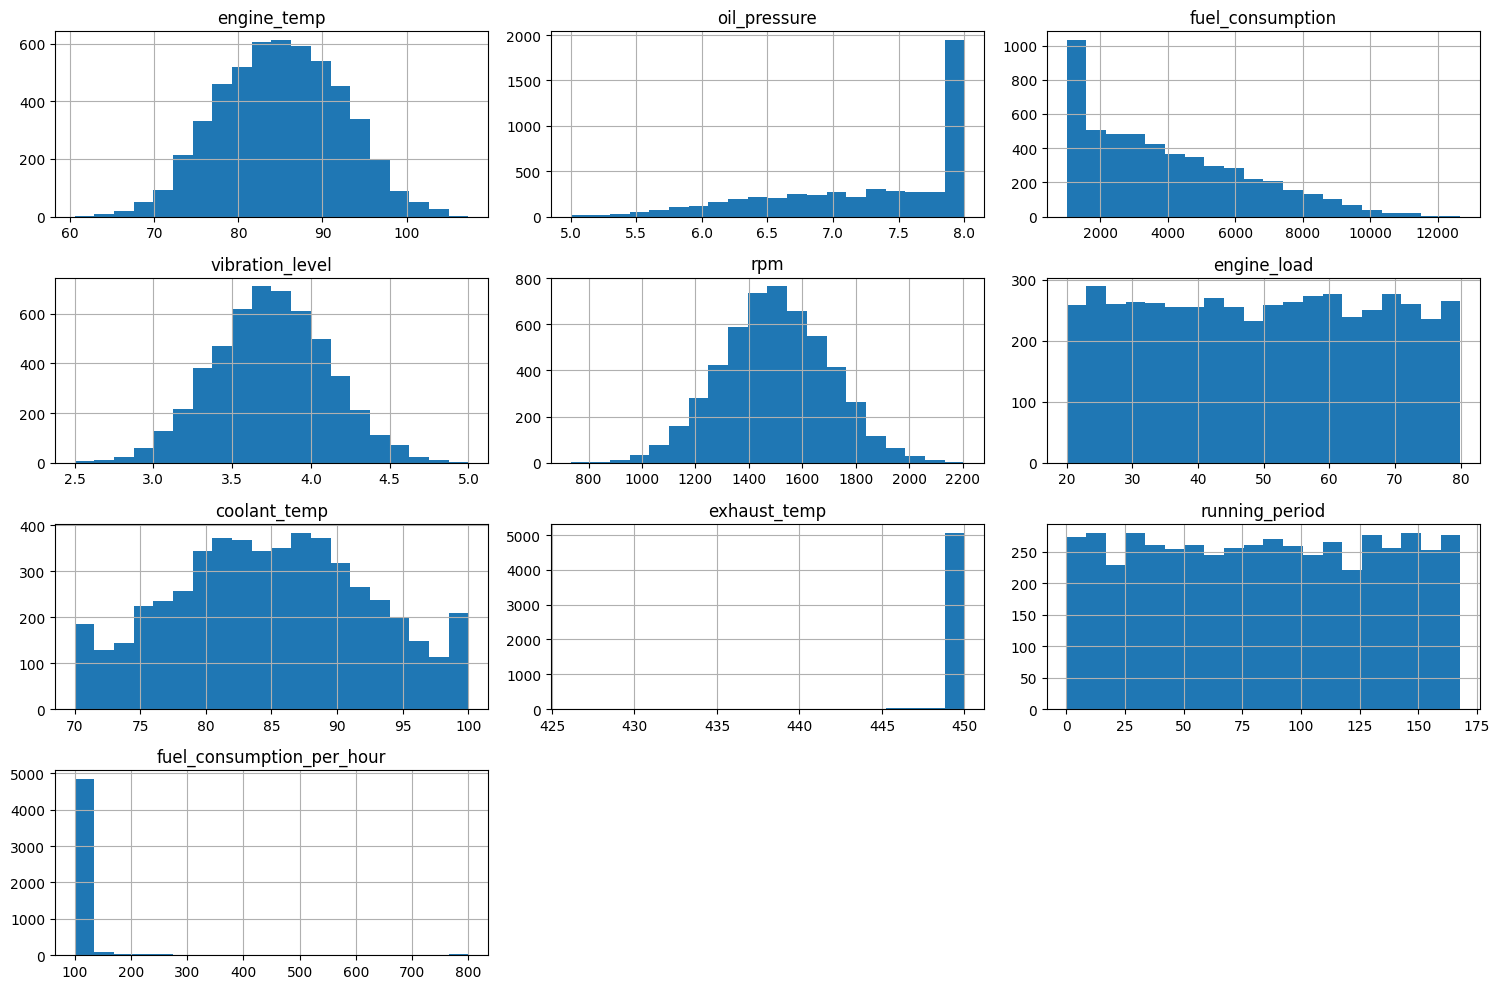

Correlation Heatmap:


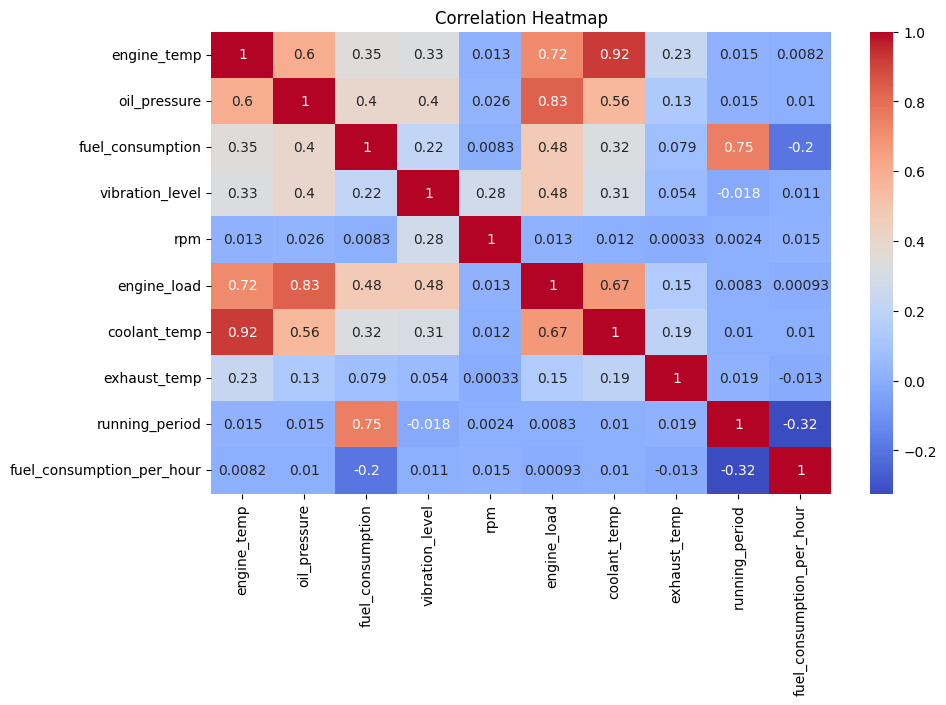

Box Plots for Numerical Variables:


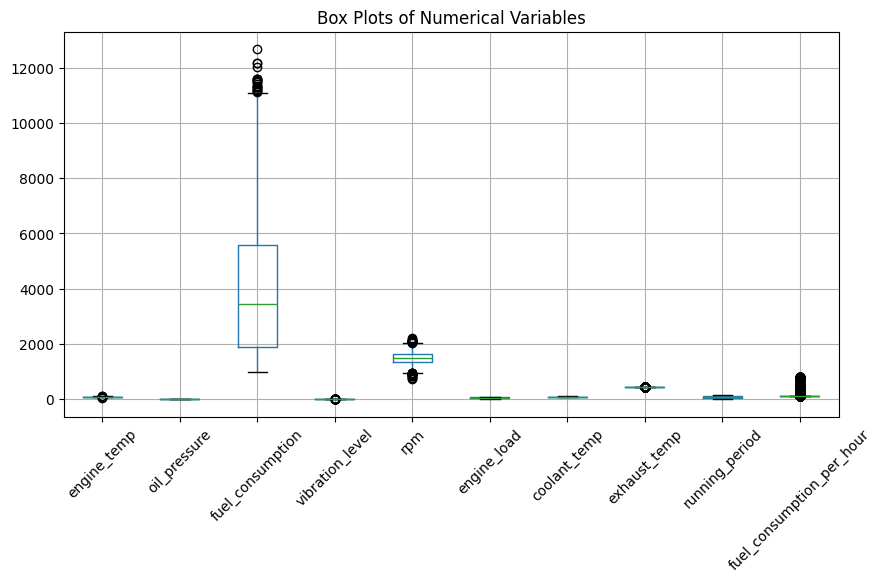

In [7]:
Numerical_Distribution(df)

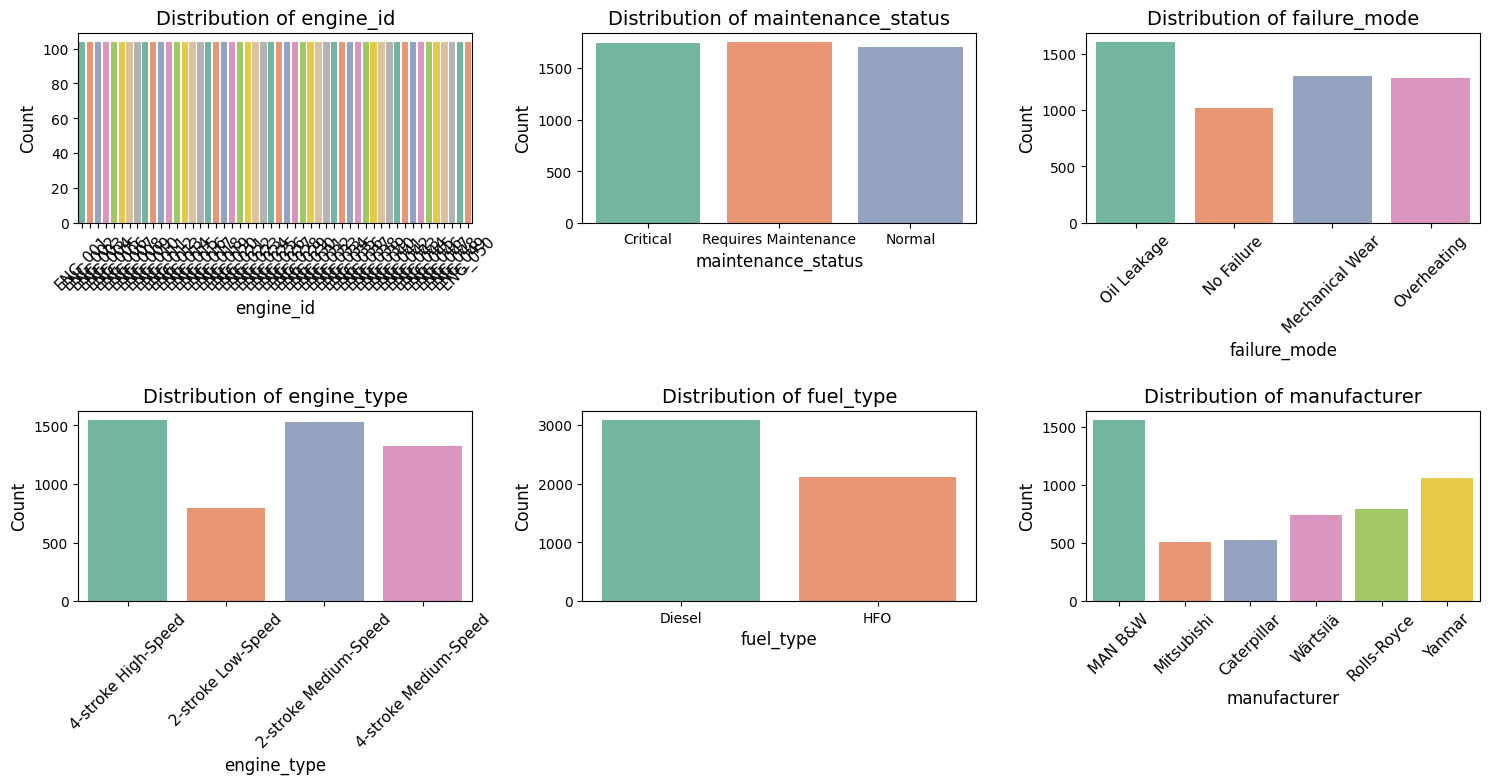

In [8]:
# Let's check Categorical Features distribution 

plotnumber = 1  # Initialize subplot counter
plt.figure(figsize=(15, 10)) 

for col in categorical_cols:  
    if plotnumber <= 6: 
        ax = plt.subplot(3, 3, plotnumber)  
        sns.countplot(data=df, x=col, palette="Set2") 
        
        plt.title(f'Distribution of {col}', fontsize=14)  
        plt.xlabel(col, fontsize=12)
        plt.ylabel('Count', fontsize=12)

        
        if df[col].nunique() >= 4: 
            plt.xticks(rotation=45, fontsize=11)  

        plotnumber += 1 

plt.tight_layout()  
plt.savefig('output/Distribution_of_Categorical_Variables.png', dpi=300) 
plt.show() 


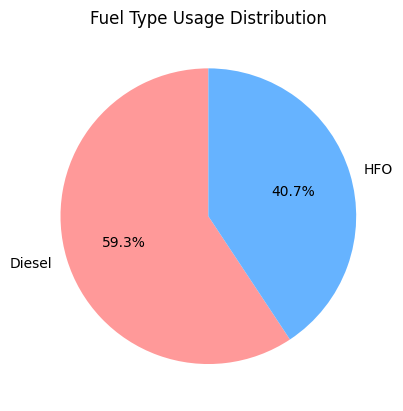

In [9]:
# Pie chart for fuel type usage
fuel_counts = df["fuel_type"].value_counts()
fuel_counts.plot.pie(autopct="%1.1f%%", startangle=90, colors=["#ff9999","#66b3ff","#99ff99"])
plt.title("Fuel Type Usage Distribution")
plt.ylabel("")  # Remove default ylabel
plt.savefig('output/Pie chart for fuel type usage.PNG')
plt.show()

### Univariate Analysis Insights

#### Numerical Variables
1. **Fuel Consumption**:
   - Range: 1000–12700 L/W.
   - Mean: ~3937 L/W.
   - Distribution: Right-skewed, with most engines consuming 2000-8000 L/W.

2. **Engine Load**:
   - Range: 20–80%.
   - Mean: 50%.
   - Distribution: Approximately normal.

#### Categorical Variables
1. **Engine Type**:
   - 2-stroke Low-Speed:15%.
   - 2-stroke Medium-Speed: 30%.
   - 4-stroke High-Speed: 30%.
   - 4-stroke Medium-Speed: 25%.

2. **Maintenance Status**:
   - Critical: 38%.
   - Requires Maintenance: 32%.
   - Normal: 30%.


#### Time-Based Variables
1. **Timestamp**:
   - Data spans 2 years (January 1, 2023, to December 31, 2024).
   - No gaps in the timeline.  - No gaps in the timeline.

### Bivariate Analysis

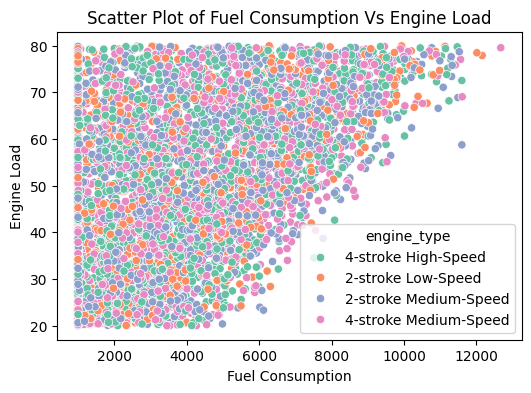

In [10]:
# Let's examine the relationship between Fuel consumption & Engine Load in respect to Engine Type
plt.figure(figsize=(6,4))
sns.scatterplot(df, x='fuel_consumption', y='engine_load', hue='engine_type', palette='Set2')
plt.title('Scatter Plot of Fuel Consumption Vs Engine Load')
plt.xlabel('Fuel Consumption')
plt.ylabel('Engine Load')
plt.savefig('output/Scatter Plot of Fuel Consumption Vs Engine Load.PNG')
plt.show()

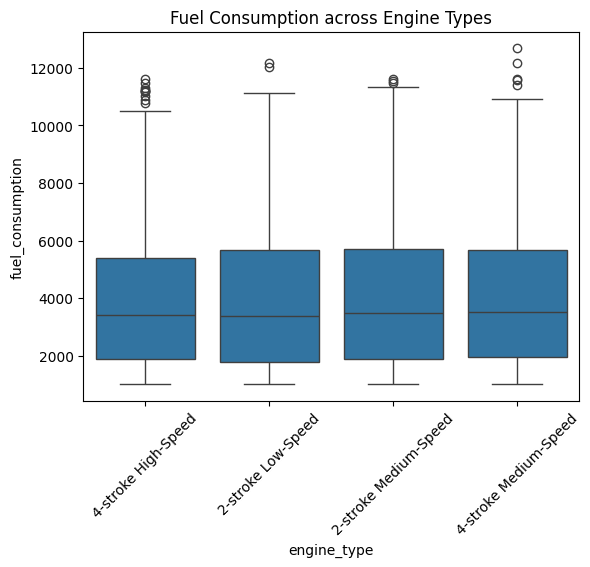

In [11]:
sns.boxplot(x=df['engine_type'], y=df['fuel_consumption'])
plt.xticks(rotation=45)
plt.title('Fuel Consumption across Engine Types')
plt.savefig('output/Fuel Consumption across Engine Types.PNG')
plt.show()


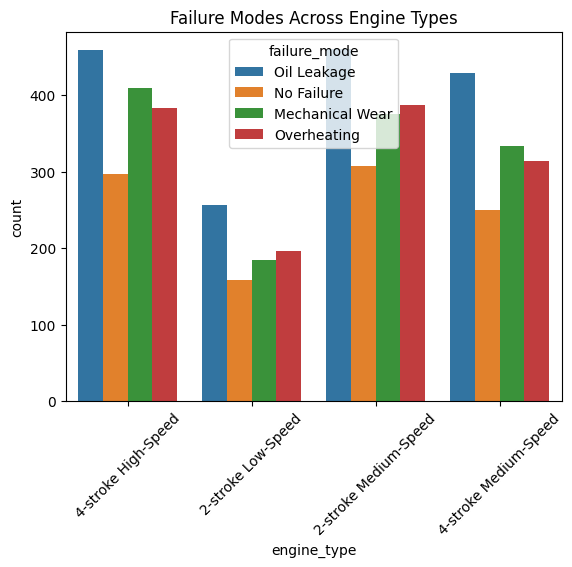

In [12]:
sns.countplot(x=df['engine_type'], hue=df['failure_mode'])
plt.xticks(rotation=45)
plt.title('Failure Modes Across Engine Types')
plt.savefig('output/Failure Modes Across Engine Types.PNG')
plt.show()


### Time Series Analysis

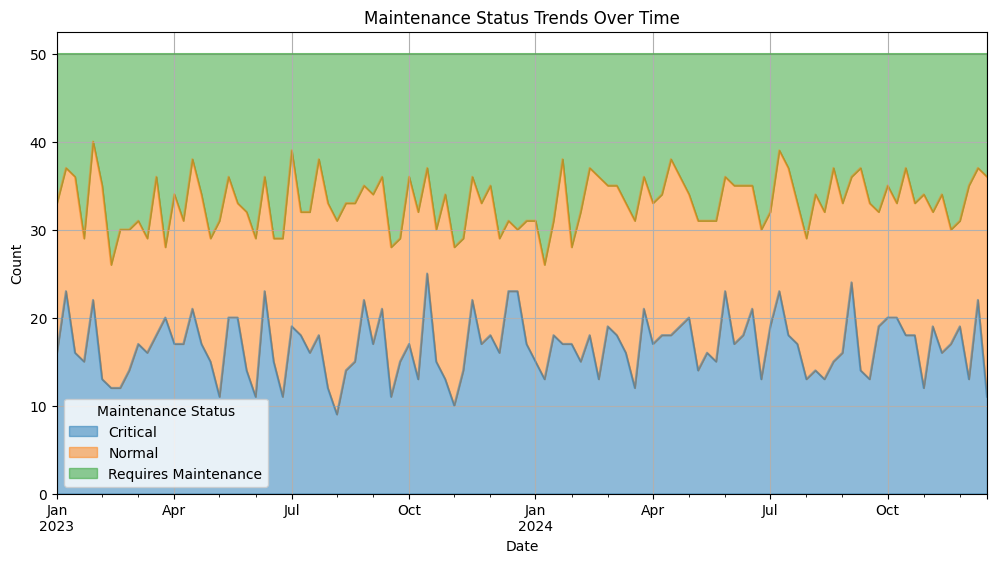

In [13]:
df['timestamp'] = pd.to_datetime(df['timestamp']) # Change datatype to datetime
df.set_index('timestamp', inplace=True)  # Set timestamp as index

df_resampled = df.resample('W')['maintenance_status'].value_counts().unstack()


df_resampled.plot.area(figsize=(12, 6), alpha=0.5, stacked=True)
plt.title('Maintenance Status Trends Over Time')
plt.xlabel('Date')
plt.ylabel('Count')
plt.legend(title='Maintenance Status')
plt.grid()
plt.savefig('output/Maintenance Status Trends Over Time.PNG')
plt.show()


### Optimized Pipeline for Marine Engine Maintenance Prediction


In [14]:
# Define numerical and categorical columns
numerical_cols = ['engine_temp', 'oil_pressure', 'fuel_consumption', 'vibration_level', 
                  'rpm', 'engine_load', 'coolant_temp', 'exhaust_temp', 'running_period']
categorical_cols = ['failure_mode', 'engine_type', 'fuel_type', 'manufacturer']




# Separate features and target
X = df.drop(columns=['maintenance_status', 'engine_id'])  # Features
y = df['maintenance_status']  # Target variable

# Encoding the target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)  # Convert 'Critical','Requires Maintenance' 'Normal'  to 0, 1, 2



# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y)

# Define Preprocessing Pipeline
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('scaler', StandardScaler()), 
        ('pca', PCA(n_components=0.95)) 
    ]), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

# Define models
models = {
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42, n_jobs=-1)
}

# Function to train and evaluate each model
def train_and_evaluate(model_name, model):
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Train model
    pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = pipeline.predict(X_test)
    
    # Evaluate
    accuracy = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    
    return model_name, accuracy, cm, report

# Train all models in parallel
results = Parallel(n_jobs=-1)(
    delayed(train_and_evaluate)(name, model) for name, model in models.items()
)

# Print results
for model_name, accuracy, cm, report in results:
    print(f"==== {model_name} Model Evaluation ====")
    print(f"Accuracy: {accuracy:.4f}")
    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n", report)
    print("="*50)


==== DecisionTree Model Evaluation ====
Accuracy: 0.3298
Confusion Matrix:
 [[113 115 120]
 [123 117 101]
 [112 126 113]]
Classification Report:
               precision    recall  f1-score   support

           0       0.32      0.32      0.32       348
           1       0.33      0.34      0.33       341
           2       0.34      0.32      0.33       351

    accuracy                           0.33      1040
   macro avg       0.33      0.33      0.33      1040
weighted avg       0.33      0.33      0.33      1040

==== RandomForest Model Evaluation ====
Accuracy: 0.3135
Confusion Matrix:
 [[118 104 126]
 [142  95 104]
 [136 102 113]]
Classification Report:
               precision    recall  f1-score   support

           0       0.30      0.34      0.32       348
           1       0.32      0.28      0.30       341
           2       0.33      0.32      0.33       351

    accuracy                           0.31      1040
   macro avg       0.31      0.31      0.31      1040
w

In [15]:
from sklearn.model_selection import GridSearchCV, train_test_split

# Define parameter grids for hyperparameter tuning
param_grid_rf = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2],
}

param_grid_xgb = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 6],
    'classifier__learning_rate': [0.01, 0.1],
    'classifier__subsample': [0.8, 1.0],
}

# Define pipelines for GridSearchCV
pipeline_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])

pipeline_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42, n_jobs=-1))
])

# Perform Grid Search for Random Forest
grid_search_rf = GridSearchCV(pipeline_rf, param_grid_rf, cv=3, scoring='accuracy', n_jobs=-1)
grid_search_rf.fit(X_train, y_train)

# Perform Grid Search for XGBoost
grid_search_xgb = GridSearchCV(pipeline_xgb, param_grid_xgb, cv=3, scoring='accuracy', n_jobs=-1)
grid_search_xgb.fit(X_train, y_train)

# Get best parameters and best scores
print("Best Parameters for Random Forest:", grid_search_rf.best_params_)
print("Best Score for Random Forest:", grid_search_rf.best_score_)

print("Best Parameters for XGBoost:", grid_search_xgb.best_params_)
print("Best Score for XGBoost:", grid_search_xgb.best_score_)


Best Parameters for Random Forest: {'classifier__max_depth': 20, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
Best Score for Random Forest: 0.3608188521670857
Best Parameters for XGBoost: {'classifier__learning_rate': 0.01, 'classifier__max_depth': 6, 'classifier__n_estimators': 100, 'classifier__subsample': 0.8}
Best Score for XGBoost: 0.3528856387544203


## Model Performance

### Model Evaluation Results

| Model          | Accuracy |
|---------------|----------|
| DecisionTree  | 33.17%   |
| RandomForest  | 29.81%   |
| XGBoost      | 30.19%   |

### Observations
- No significant improvement was observed after hyperparameter tuning and feature selection.
- PCA-based dimensionality reduction resulted in lower feature dimensionality, but classification accuracy remained suboptimal.
- Class imbalance and the distribution of sensor data may have contributed to the lower accuracy rates.

## Conclusion

This analysis successfully demonstrates:
- Creation and simulation of realistic marine engine operational data
- Implementation of a complete machine learning pipeline for predictive maintenance classification
- Application of preprocessing techniques including standardization, one-hot encoding, and dimensionality reduction via PCA
- Comparative evaluation of multiple classification algorithms (Decision Tree, Random Forest, XGBoost)

The relatively low accuracy indicates areas for further investigation and improvement in feature engineering and model selection phases.

## Recommendations for Future Work
- Expand dataset size to improve model generalization
- Conduct additional feature engineering to extract more predictive features
- Explore alternative machine learning approaches and deep learning architectures
- Implement advanced hyperparameter optimization techniques
- Analyze feature importance to identify most impactful variables